In [1]:
import os
import sys
import shutil
import math
import warnings
import datetime
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from typing import *
from enum import Enum
from scipy.spatial import Voronoi
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import LabelEncoder
from scipy.stats import wasserstein_distance
sys.path.append("/home/esraan/CellDeathSpreading/")
from src.utils import get_experiment_cell_death_times_by_specific_siliding_window,read_experiment_cell_xy_and_death_times
from src.NucleationAndPropagationMeasurements import replace_ugly_long_name
from src.quanta_utils import get_neighbors
from src.DeathQuanta import DeathQuanta
from src.NucleationAndPropagationMeasurements import *
import seaborn as sns
from src.uSpiCalc import uSpiCalc
from src.mSpiCalc import mSpiCalc
from src.mixSpiCalc import mixSpiCalc

In [27]:
exps_dir_name = "/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/mixed_pure_death_minutes_microns/"
meta_data_file_full_path= "/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/all_csv_files_minutes_microns_with_sytox.csv"
meta_data_extract_exp_names= pd.read_csv(meta_data_file_full_path)
exp_names = meta_data_extract_exp_names.iloc[:,1]
group_data = {}
for idx in range(1,len(exp_names)):
    if 'mixed' not in exp_names[idx]:
        continue
    print(exp_names[idx])
    exp_full_path = os.path.join(exps_dir_name, exp_names[idx])
    csv_file = pd.read_csv(exp_full_path)
    dist_threshold = 100 # microns
    cells_location = csv_file[["cell_x","cell_y"]].values
    di_times = csv_file[['death_time']].values
    death_modes = csv_file[["Mode"]].values if "Mode" in csv_file.columns else []
    de_qu = DeathQuanta(cells_xy=cells_location,
                        death_times=di_times, 
                        death_modes=death_modes,
                        dist_threshold=dist_threshold,
                        filter_neighbors_by_distance=True,
                        filter_neighbors_by_level=True,
                        normalize = True,
                        neighbors_level=3,
                        )# meta_data_extract_exp_names[meta_data_extract_exp_names['File Name']==exp_names[idx]]["Mode"].values[0])
    tod_pairs_1 = de_qu.get_org_deltaTOD_neighbors_pairs()
    community,set_x = de_qu.find_commonities(level=2)
    tod_pairs_2 = de_qu.get_TOD_from_nucleator(level=2)
    break

field13_crop-001_ROI#1_annotation_mixed.csv


In [28]:
community

{0: array([  1, 431], dtype=int32),
 2: array([128,   5,   7,  71,  77, 143,  79, 145,  81, 155, 159, 160,  95,
        101, 166,  39,  42, 120,  61], dtype=int32),
 3: array([ 64,  35, 103,  40,  73,  12, 177,  18,  86, 249, 122, 123,  93],
       dtype=int32),
 4: array([ 34, 100, 133,   6,   9,  10,  11,  14,  15, 111,  82,  56,  57,
         60,  24], dtype=int32),
 8: array([136, 107, 142, 110,  29,  19,  20, 116, 248,  26, 158, 381, 190,
         63], dtype=int32),
 13: array([], dtype=float64),
 16: array([163, 229, 169,  74, 201, 283, 242,  22, 311, 184, 183, 218, 187,
        125], dtype=int32),
 17: array([544, 354, 529, 532, 282, 541], dtype=int32),
 21: array([385, 522, 527, 421, 427, 302, 309, 439, 441, 452, 459, 341, 344,
        348, 349, 362, 494, 499, 505, 378, 379, 253], dtype=int32),
 23: array([ 97,  66,  68,  69,  38, 137, 138, 393, 140, 105,  46,  80,  84,
        150, 310,  59,  92], dtype=int32),
 25: array([ 99, 134,  70, 203, 300,  76, 204, 112,  54,  55, 191]

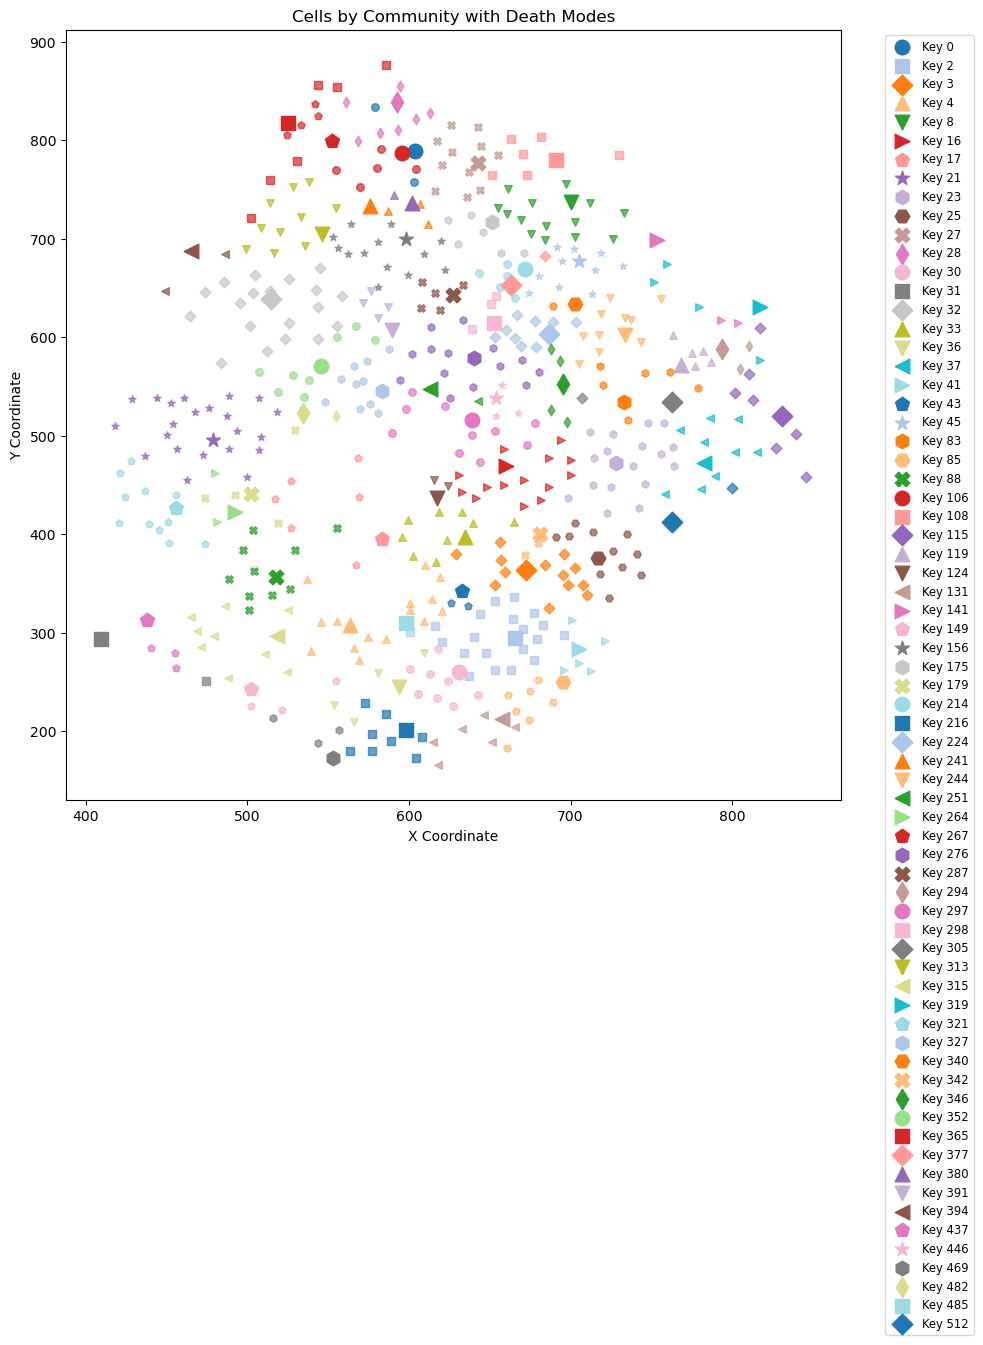

In [29]:
plt.figure(figsize=(10, 10))

# Define markers and colors
markers = ['o', 's', 'D', '^', 'v', '<', '>', 'p', '*', 'h', 'H', 'X', 'd']
colors = plt.cm.tab20.colors  # Use a colormap for colors

# Reverse transform death modes to their original labels
death_mode_labels = de_qu.le.inverse_transform(de_qu.death_modes.flatten())

for i, (key, value) in enumerate(community.items()):
    if value.size == 0:
        continue  # Skip empty communities
    
    marker = markers[i % len(markers)]  # Cycle through markers
    key_color = colors[i % len(colors)]  # Cycle through colors
    
    # Plot the key with a larger marker size
    plt.scatter(de_qu.cells_xy[key, 0], de_qu.cells_xy[key, 1], color=key_color, marker=marker, s=110, label=f'Key {key}')
    
    # Plot the values in the community with the same color and smaller marker size
    for val in value:
        val_color = key_color
        plt.scatter(de_qu.cells_xy[val, 0], de_qu.cells_xy[val, 1], color=val_color, marker=marker, s=30, alpha=0.7)

plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Cells by Community with Death Modes')
plt.legend(loc='best', bbox_to_anchor=(1.05, 1), fontsize='small')
# plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression

# x, y = spatial coordinates
# t = event times (NaN if no event)
mask = ~np.isnan(t)
x_valid = x[mask]
y_valid = y[mask]
t_valid = t[mask]

# Stack spatial coords
X = np.column_stack((x_valid, y_valid))

# Fit linear regression: t = a*x + b*y + c
reg = LinearRegression().fit(X, t_valid)
a, b = reg.coef_

# Propagation direction
theta = np.arctan2(b, a)  # radians
direction_deg = np.degrees(theta)

# Propagation speed
gradient_mag = np.sqrt(a**2 + b**2)
speed = 1 / gradient_mag  # units: [distance/time]
print (a,b)
print(f"Direction: {direction_deg:.1f}°, Speed: {speed:.2f} μm/min")


In [ ]:
# Initialize an empty list to store results
results = []

# Iterate over each key-value pair in the community dictionary
for key, value in community.items():
    if value.size == 0:
        continue  # Skip empty communities

    # Extract spatial coordinates and event times for the current community
    mask = ~np.isnan(di_times[value].flatten())
    x_valid = de_qu.cells_xy[value, 0][mask]
    y_valid = de_qu.cells_xy[value, 1][mask]
    t_valid = di_times[value].flatten()[mask]
    # Extract mode of death for the current key
    mode_of_death = np.array ([de_qu.death_modes[key]]) if len(de_qu.death_modes) > 0 else ['Unknown']
    mode_of_death = de_qu.le.inverse_transform(mode_of_death) if hasattr(de_qu, 'le') else mode_of_death


    if len(t_valid) < 2:
        continue  # Skip if there are not enough points for regression

    # Stack spatial coordinates
    X = np.column_stack((x_valid, y_valid))

    # Fit linear regression: t = a*x + b*y + c
    reg = LinearRegression().fit(X, t_valid)
    a, b = reg.coef_

    # Calculate propagation direction and speed
    theta = np.arctan2(b, a)  # radians
    direction_deg = np.degrees(theta)
    gradient_mag = np.sqrt(a**2 + b**2)
    speed = 1 / gradient_mag  # units: [distance/time]

    # Append results to the list
    results.append({
        'Community': key,
        'Direction (deg)': direction_deg,
        'Speed (μm/min)': speed,
        'Mode of Death': mode_of_death[0],
        'Num Cells': len(value),
        "meanDeltaTOD": np.mean(tod_pairs_2.get(key, 0)),

    })

# Convert results to a DataFrame
results_df = pd.DataFrame(results)

# Display the DataFrame
results_df
mean_values = results_df.groupby('Mode of Death').mean(numeric_only=True).reset_index()
mean_values.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in mean_values.columns.values]
mean_values.drop(columns=['Community'], inplace=True)
mean_values

,Community,Direction (deg),Speed (μm/min),Mode of Death,Num Cells,meanDeltaTOD
0,0,-5.996213e-15,0.252281,apoptosis,2,0.480549
1,2,-5.371783e+01,0.308114,necrosis,19,0.162833
2,3,1.628732e+02,1.708498,necrosis,13,0.152790
3,4,-3.848857e+01,2.434011,necrosis,15,0.092754
4,8,-1.048907e+02,0.305027,necrosis,14,0.158875
5,16,-4.251121e+01,1.138869,necrosis,14,0.179797
6,17,1.043437e+02,0.591452,apoptosis,6,0.948284
7,21,1.249292e+02,0.221796,apoptosis,22,0.628250
8,23,-1.602505e+02,0.327710,necrosis,17,0.130300
9,25,-1.232669e+02,0.449807,necrosis,11,0.118993


In [34]:
mean_values = results_df.groupby('Mode of Death').mean(numeric_only=True).reset_index()
mean_values.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in mean_values.columns.values]
mean_values.drop(columns=['Community'], inplace=True)
mean_values

,Mode of Death,Direction (deg),Speed (μm/min),Num Cells,meanDeltaTOD
0,apoptosis,28.945946,0.208549,7.640000,0.217952
1,necrosis,-7.251345,0.382602,7.514286,0.081481


## All Mixed files

In [35]:
# Initialize an empty list to store DataFrames
all_results = []

# Iterate over each file with "mixed" in its name
for idx in range(1, len(exp_names)):
    if 'mixed' not in exp_names[idx]:
        continue
    
    print(f"Processing file: {exp_names[idx]}")
    exp_full_path = os.path.join(exps_dir_name, exp_names[idx])
    csv_file = pd.read_csv(exp_full_path)
    dist_threshold = 100  # microns
    cells_location = csv_file[["cell_x", "cell_y"]].values
    di_times = csv_file[['death_time']].values
    death_modes = csv_file[["Mode"]].values if "Mode" in csv_file.columns else []
    
    de_qu = DeathQuanta(
        cells_xy=cells_location,
        death_times=di_times,
        death_modes=death_modes,
        dist_threshold=dist_threshold,
        filter_neighbors_by_distance=True,
        filter_neighbors_by_level=True,
        normalize=True,
        neighbors_level=3,
    )
    
    tod_pairs_1 = de_qu.get_org_deltaTOD_neighbors_pairs()
    community, set_x = de_qu.find_commonities(level=2)
    tod_pairs_2 = de_qu.get_TOD_from_nucleator(level=2)
    
    # Initialize an empty list to store results for the current file
    results = []

    # Iterate over each key-value pair in the community dictionary
    for key, value in community.items():
        if value.size == 0:
            continue  # Skip empty communities

        # Extract spatial coordinates and event times for the current community
        mask = ~np.isnan(di_times[value].flatten())
        x_valid = de_qu.cells_xy[value, 0][mask]
        y_valid = de_qu.cells_xy[value, 1][mask]
        t_valid = di_times[value].flatten()[mask]
        # Extract mode of death for the current key
        mode_of_death = np.array([de_qu.death_modes[key]]) if len(de_qu.death_modes) > 0 else ['Unknown']
        mode_of_death = de_qu.le.inverse_transform(mode_of_death) if hasattr(de_qu, 'le') else mode_of_death

        if len(t_valid) < 2:
            continue  # Skip if there are not enough points for regression

        # Stack spatial coordinates
        X = np.column_stack((x_valid, y_valid))

        # Fit linear regression: t = a*x + b*y + c
        reg = LinearRegression().fit(X, t_valid)
        a, b = reg.coef_

        # Calculate propagation direction and speed
        theta = np.arctan2(b, a)  # radians
        direction_deg = np.degrees(theta)
        gradient_mag = np.sqrt(a**2 + b**2)
        speed = 1 / gradient_mag  # units: [distance/time]

        # Append results to the list
        results.append({
            'Community': key,
            'Direction (deg)': direction_deg,
            'Speed (μm/min)': speed,
            'Mode of Death': mode_of_death[0],
            'Num Cells': len(value),
            "meanDeltaTOD": np.mean(tod_pairs_2.get(key, 0)),
        })

    # Convert results to a DataFrame and add the file name
    results_df = pd.DataFrame(results)
    results_df['file_name'] = exp_names[idx]
    
    # Append the DataFrame to the list
    all_results.append(results_df)

# Concatenate all DataFrames into a single one
final_results_df = pd.concat(all_results, ignore_index=True)

# Display the final concatenated DataFrame
final_results_df

Processing file: field13_crop-001_ROI#1_annotation_mixed.csv
Processing file: Field14-002_ROI#1_annotation_mixed.csv
Processing file: 7-20-23_10arednuclei_ROI#10_annotation_mixed.csv
Processing file: 7-20-23_10arednuclei_ROI#13_or14_both_colonies_annotation_mixed.csv


,Community,Direction (deg),Speed (μm/min),Mode of Death,Num Cells,meanDeltaTOD,file_name
0,0,-5.996213e-15,0.252281,apoptosis,2,0.480549,field13_crop-001_ROI#1_annotation_mixed.csv
1,2,-5.371783e+01,0.308114,necrosis,19,0.162833,field13_crop-001_ROI#1_annotation_mixed.csv
2,3,1.628732e+02,1.708498,necrosis,13,0.152790,field13_crop-001_ROI#1_annotation_mixed.csv
3,4,-3.848857e+01,2.434011,necrosis,15,0.092754,field13_crop-001_ROI#1_annotation_mixed.csv
4,8,-1.048907e+02,0.305027,necrosis,14,0.158875,field13_crop-001_ROI#1_annotation_mixed.csv
...,...,...,...,...,...,...,...
210,406,-7.680753e+00,0.161889,apoptosis,8,0.559019,7-20-23_10arednuclei_ROI#13_or14_both_colonies...
211,447,1.538423e+02,0.141474,apoptosis,5,0.347465,7-20-23_10arednuclei_ROI#13_or14_both_colonies...
212,456,-1.017051e+02,0.156704,apoptosis,8,0.367830,7-20-23_10arednuclei_ROI#13_or14_both_colonies...
213,477,1.586294e+02,6.371846,apoptosis,2,0.182876,7-20-23_10arednuclei_ROI#13_or14_both_colonies...


In [36]:
grouped_means = final_results_df.groupby(['file_name', 'Mode of Death']).mean(numeric_only=True).reset_index()
grouped_means

,file_name,Mode of Death,Community,Direction (deg),Speed (μm/min),Num Cells,meanDeltaTOD
0,7-20-23_10arednuclei_ROI#10_annotation_mixed.csv,apoptosis,61.888889,37.304321,0.651208,3.888889,0.320996
1,7-20-23_10arednuclei_ROI#10_annotation_mixed.csv,necrosis,42.200000,-22.202525,0.695036,7.933333,0.203415
2,7-20-23_10arednuclei_ROI#13_or14_both_colonies...,apoptosis,293.681818,16.320928,0.965486,9.636364,0.373756
3,7-20-23_10arednuclei_ROI#13_or14_both_colonies...,necrosis,129.432432,11.574100,0.278294,8.243243,0.043261
4,Field14-002_ROI#1_annotation_mixed.csv,apoptosis,288.404762,-11.252403,0.213457,7.690476,0.156666
5,Field14-002_ROI#1_annotation_mixed.csv,necrosis,78.233333,6.342128,0.257956,6.866667,0.091012
6,field13_crop-001_ROI#1_annotation_mixed.csv,apoptosis,253.760000,28.945946,0.208549,7.640000,0.217952
7,field13_crop-001_ROI#1_annotation_mixed.csv,necrosis,118.428571,-7.251345,0.382602,7.514286,0.081481
